In [1]:
!pip install transformers datasets torch accelerate scikit-learn matplotlib seaborn


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import numpy as np
import torch
from datasets import load_dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)
import matplotlib.pyplot as plt
import seaborn as sns

c:\Users\fah20\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\fah20\AppData\Local\Programs\Python\Python310\lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


In [9]:
HF_DATASET     = "dralsarrani/AraReview"
MODEL_NAME     = "aubmindlab/bert-base-arabertv2"
OUTPUT_DIR     = "./arabert-sentiment"
HF_MODEL_REPO  = "dralsarrani/arabert-sentiment"   # where to push after training

LABEL2ID = {"negative": 0, "positive": 1}
ID2LABEL = {0: "negative", 1: "positive"}

BATCH_SIZE     = 16
MAX_LENGTH     = 128
EPOCHS         = 2
LEARNING_RATE  = 2e-5
WEIGHT_DECAY   = 0.01
WARMUP_RATIO   = 0.1

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print()

Device: cuda
GPU: NVIDIA GeForce RTX 4060
VRAM: 8.6 GB



In [5]:
dataset = load_dataset(HF_DATASET)

c:\Users\fah20\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:130: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\fah20\.cache\huggingface\hub\datasets--dralsarrani--AraReview. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Generating test split: 100%|██████████| 10547/10547 [00:00<00:00, 484994.57 examples/s]


In [7]:
print(f"Train: {len(dataset['train']):,}")
print(f"Validation: {len(dataset['validation']):,}")
print(f"Test: {len(dataset['test']):,}")
print()

Train: 84,372
Validation: 10,547
Test: 10,547



In [8]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

In [10]:
def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,
    )

In [11]:
def encode_labels(batch):
    batch["labels"] = [LABEL2ID[l] for l in batch["label"]]
    return batch

In [12]:
tokenized = dataset.map(tokenize, batched=True, batch_size=256)
tokenized = tokenized.map(encode_labels, batched=True)

Map: 100%|██████████| 10547/10547 [00:00<00:00, 229346.78 examples/s]


In [13]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'rating'],
        num_rows: 84372
    })
    validation: Dataset({
        features: ['text', 'label', 'rating'],
        num_rows: 10547
    })
    test: Dataset({
        features: ['text', 'label', 'rating'],
        num_rows: 10547
    })
})

In [14]:
tokenized["train"].column_names

['text',
 'label',
 'rating',
 'input_ids',
 'token_type_ids',
 'attention_mask',
 'labels']

In [15]:
tokenized = tokenized.remove_columns(
    [c for c in tokenized["train"].column_names
     if c not in ["input_ids", "attention_mask", "token_type_ids", "labels"]]
)

In [16]:
tokenized.set_format("torch")

In [17]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
)
model.to(device)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 777.66it/s, Materializing param=bert.pooler.dense.weight]                               
BertForSequenceClassification LOAD REPORT from: aubmindlab/bert-base-arabertv2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different tas

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(64000, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [18]:
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}\n")

Model parameters: 135,194,882



In [19]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="weighted"
    )
    return {
        "accuracy":  round(acc, 4),
        "f1":        round(f1, 4),
        "precision": round(precision, 4),
        "recall":    round(recall, 4),
    }

In [20]:
training_args = TrainingArguments(
    output_dir                  = OUTPUT_DIR,
    num_train_epochs            = EPOCHS,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE,
    learning_rate               = LEARNING_RATE,
    weight_decay                = WEIGHT_DECAY,
    warmup_ratio                = WARMUP_RATIO,
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    load_best_model_at_end      = True,
    metric_for_best_model       = "f1",
    greater_is_better           = True,
    logging_dir                 = "./logs",
    logging_steps               = 50,
    fp16                        = True,       # float16 for RTX 4060
    dataloader_num_workers      = 4,
    report_to                   = "none",     #"wandb" for tracking
    save_total_limit            = 2,
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [21]:
trainer = Trainer(
    model           = model,
    args            = training_args,
    train_dataset   = tokenized["train"],
    eval_dataset    = tokenized["validation"],
    compute_metrics = compute_metrics,
    callbacks       = [EarlyStoppingCallback(early_stopping_patience=2)],
)

In [22]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.102837,0.162517,0.956500,0.956500,0.957500,0.956500
2,0.108815,0.135108,0.961200,0.961200,0.961500,0.961200


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.32it/s]
There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer

TrainOutput(global_step=10548, training_loss=0.1467713299781299, metrics={'train_runtime': 1402.391, 'train_samples_per_second': 120.326, 'train_steps_per_second': 7.521, 'total_flos': 1.109960298141696e+16, 'train_loss': 0.1467713299781299, 'epoch': 2.0})

In [23]:
predictions = trainer.predict(tokenized["test"])
preds  = np.argmax(predictions.predictions, axis=1)
labels = predictions.label_ids


=== Classification Report ===
              precision    recall  f1-score   support

    negative       0.97      0.95      0.96      5321
    positive       0.95      0.97      0.96      5226

    accuracy                           0.96     10547
   macro avg       0.96      0.96      0.96     10547
weighted avg       0.96      0.96      0.96     10547

Saved confusion matrix to confusion_matrix.png


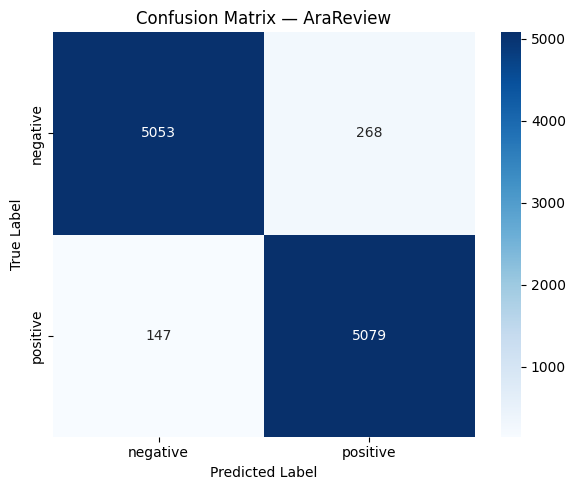

In [24]:
print("\n=== Classification Report ===")
print(classification_report(
    labels, preds,
    target_names=["negative", "positive"]
))

# Confusion matrix
cm = confusion_matrix(labels, preds)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["negative", "positive"],
    yticklabels=["negative", "positive"],
)
plt.title("Confusion Matrix — AraReview")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
print("Saved confusion matrix to confusion_matrix.png")


In [25]:
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

Writing model shards: 100%|██████████| 1/1 [00:07<00:00,  7.96s/it]


('./arabert-sentiment\\tokenizer_config.json',
 './arabert-sentiment\\tokenizer.json')

In [26]:
trainer.model.push_to_hub(HF_MODEL_REPO)
tokenizer.push_to_hub(HF_MODEL_REPO)

c:\Users\fah20\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:130: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\fah20\.cache\huggingface\hub\models--dralsarrani--arabert-sentiment. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Writing model shards: 100%|██████████| 1/1 [00:05<00:00,  5.68s/it]
Processing Files

CommitInfo(commit_url='https://huggingface.co/dralsarrani/arabert-sentiment/commit/af32087d0d078835623159adae9ee160284675a6', commit_message='Upload tokenizer', commit_description='', oid='af32087d0d078835623159adae9ee160284675a6', pr_url=None, repo_url=RepoUrl('https://huggingface.co/dralsarrani/arabert-sentiment', endpoint='https://huggingface.co', repo_type='model', repo_id='dralsarrani/arabert-sentiment'), pr_revision=None, pr_num=None)

## Test

In [27]:
from transformers import pipeline

classifier = pipeline(
    "text-classification",
    model=OUTPUT_DIR,
    tokenizer=OUTPUT_DIR,
    device=0 if torch.cuda.is_available() else -1,
)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 728.08it/s, Materializing param=classifier.weight]                                      


In [28]:
test_reviews = [
    "الفندق رائع والخدمة ممتازة وسأعود مرة أخرى",   # positive
    "اسوا تجربة في حياتي الغرفة قديمة والخدمة سيئة",  # negative
    "مقبول لكن يحتاج تحسين في بعض الجوانب",           # should be negative (2 star vibe)
]

In [29]:
for review in test_reviews:
    result = classifier(review)[0]
    label = result["label"]
    score = round(result["score"] * 100, 1)
    print(f"  [{label} {score}%] {review}")

  [positive 97.5%] الفندق رائع والخدمة ممتازة وسأعود مرة أخرى
  [negative 100.0%] اسوا تجربة في حياتي الغرفة قديمة والخدمة سيئة
  [negative 58.1%] مقبول لكن يحتاج تحسين في بعض الجوانب
